# **INTRODUCCIÓN A SEÑALES BIOMÉDICAS**

## Adquisición de datos: ***PTB Diagnostic ECG Database:***

Esta base de datos presenta 549 grabaciones de 290 pacientes diferentes los cuáles fueron tomados 15 derivaciones (i,ii,iii,avr, avl, avf, v1, v2, v3, v4, v5, v6,vx, vy, vz) muestreadas a 1KHz, cada uno fue separado por edad y sexo además, de presentar alguna patología la cuál es mostrada por el siguiente recuadro:

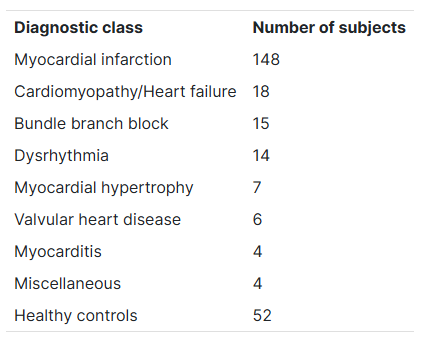

In [ ]:
#Descargamos el zip:
!wget https://physionet.org/static/published-projects/ptbdb/ptb-diagnostic-ecg-database-1.0.0.zip
#Se descomprime:
!unzip -q ptb-diagnostic-ecg-database-1.0.0.zip

--2026-06-08 01:48:27--  https://physionet.org/static/published-projects/ptbdb/ptb-diagnostic-ecg-database-1.0.0.zip
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://physionet.org/content/ptbdb/get-zip/1.0.0/ [following]
--2026-06-08 01:48:28--  https://physionet.org/content/ptbdb/get-zip/1.0.0/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1790456359 (1.7G) [application/zip]
Saving to: ‘ptb-diagnostic-ecg-database-1.0.0.zip’

ptb-diagnostic-ecg- 100%[===================>]   1.67G   261KB/s    in 1h 46m  

2026-06-08 03:34:40 (274 KB/s) - ‘ptb-diagnostic-ecg-database-1.0.0.zip’ saved [1790456359/1790456359]



##Separación de datos: ***ECG sano vs ECG patológico***:

Gracias a los archivos md en la base **(CONTROLS y RECORDS)** se pueden separar las mediciones en dos grandes grupos, inicialmente deseamos realizar la división entre ECG sano e infarto de miocardio y trabajar a partir del segundo, sin embargo por cuestiones de tiempo nos enfocaremos en determinar ECG sano y patológico


In [ ]:
import os
from google.colab import drive
#Conectamos al drive:
drive.mount('/content/drive')
#La carpeta descomprimida
ruta_base = '/content/ptb-diagnostic-ecg-database-1.0.0/'
ruta_controls = os.path.join(ruta_base, 'CONTROLS')
pacientes_sanos = set()
#Extraemos el ID de los controles (pacientes sanos)
with open(ruta_controls, 'r') as f:
    for line in f:
        if line.strip():
            paciente = line.split('/')[0]
            pacientes_sanos.add(paciente)
ruta_records = os.path.join(ruta_base, 'RECORDS')
pacientes_todos = set()
#Extraemos el ID de los records (pacientes totales)
with open(ruta_records, 'r') as f:
    for line in f:
        if line.strip():
            paciente = line.split('/')[0]
            pacientes_todos.add(paciente)
#Hallamos los pacientes patológicos
pacientes_patologicos = pacientes_todos - pacientes_sanos
#Imprimimos para verificarlo con la tabla de la base de datos:
print(f"Total Sanos: {len(pacientes_sanos)}")
print(f"Total Patológicos: {len(pacientes_patologicos)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total Sanos: 52
Total Patológicos: 238


##Extracción de derivaciones ***I,II y III:***

Se extraerán las tres derivaciones con el ID del paciente y se guardarán en un diccionario en formato pickle, con esto ya no tendremos que descargar la base de datos cada vez que quisieramos usarla, sino estará en el drive en todo momento

In [ ]:
import os
import wfdb
import numpy as np
import pickle
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
os.makedirs(ruta_drive, exist_ok=True)
ruta_base = '/content/ptb-diagnostic-ecg-database-1.0.0/'
def extraer_por_paciente(lista_pacientes, ruta_origen, nombre_archivo_salida):
    datos_pacientes = {}
    derivaciones_deseadas = ['i', 'ii', 'iii']
    #De ahi lo borro, es para ver que esta funcionando
    print(f"Extracción en: {nombre_archivo_salida}")
    for paciente in lista_pacientes:
        ruta_paciente = os.path.join(ruta_origen, paciente)
        matrices_del_paciente = []
        if not os.path.exists(ruta_paciente):
            continue
        archivos_registro = [f.replace('.hea', '') for f in os.listdir(ruta_paciente) if f.endswith('.hea')]
        for archivo in archivos_registro:
            ruta_completa = os.path.join(ruta_paciente, archivo)
            try:
                senal_completa, metadatos = wfdb.rdsamp(ruta_completa)
                nombres_canales = metadatos['sig_name']
                indices = [nombres_canales.index(der) for der in derivaciones_deseadas if der in nombres_canales]
                if len(indices) == 3:
                    senal_filtrada = senal_completa[:, indices]
                    #Si estan las tres derivaciones las agregamos a la lista
                    matrices_del_paciente.append(senal_filtrada)
            except Exception as e:
                pass
        #Guardamos el registro con el ID del paciente
        if matrices_del_paciente:
            datos_pacientes[paciente] = matrices_del_paciente
    #Guardamos en el drive
    ruta_guardado = os.path.join(ruta_drive, nombre_archivo_salida)
    with open(ruta_guardado, 'wb') as f:
        pickle.dump(datos_pacientes, f)
    #Luego borro esto es solo para ver
    print(f"Guardado en: {ruta_guardado}")
    return datos_pacientes
#Ejecutamos
sanos_data = extraer_por_paciente(pacientes_sanos, ruta_base, 'sanos_derivaciones_por_paciente.pkl')
patologicos_data = extraer_por_paciente(pacientes_patologicos, ruta_base, 'patologicos_derivaciones_por_paciente.pkl')

Extracción en: sanos_derivaciones_por_paciente.pkl
Guardado en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/sanos_derivaciones_por_paciente.pkl
Extracción en: patologicos_derivaciones_por_paciente.pkl
Guardado en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/patologicos_derivaciones_por_paciente.pkl


##Acondicionamiento de la señal: ***Filtros y Actualización de data***

Se utilizarán filtros para disminuir el ruido lo mayor posible de los archivos crudos (.dat) para posteriormente poder clasificarlos:

###**Filtro Notch (50Hz):**
Para eliminar la interferencia eléctrica, el 50Hz se debe a que la toma de datos se realizó en Alemania y la frecuencia de la unión europea es esta

###**Filtro ButterWorth Pasa Banda (0.5Hz 40Hz):**
El primer corte sirve para eliminar la deriva de linea base que se genera por la respiración o el mal contacto físico de los electrodos y el segundo corte sirve para eliminar el ruido muscular

###**Uso de filtfilt:**
Utilizaremos Zero-phase filtering ya que los comunes generan un pequeño retraso, lo cuál podría deformar la duración del complejo QRS o el intervalo PR, filtfilt filtra en una dirección y luego en reversa cancelando este desfase

In [ ]:
import os
import pickle
import numpy as np
from scipy.signal import butter, iirnotch, filtfilt
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
fs = 1000.0  # Frecuencia que se menciona en la base de datos
def aplicar_filtros(senal_matriz):
    f0 = 50.0
    Q = 30.0
    #Filtro Notch:
    b_notch, a_notch = iirnotch(f0, Q, fs)
    #Filtro Pasabanda:
    b_band, a_band = butter(4, [0.5, 40.0], btype='bandpass', fs=fs)
    senal_limpia = np.zeros_like(senal_matriz)
    #Como nuestras derivaciones estan separadas por columnas,iteramos en cada una:
    for columna in range(senal_matriz.shape[1]):
        canal_crudo = senal_matriz[:, columna]
        #Usamos el filtfilt
        y_notch = filtfilt(b_notch, a_notch, canal_crudo)
        y_final = filtfilt(b_band, a_band, y_notch)
        senal_limpia[:, columna] = y_final
    return senal_limpia
def procesar_diccionario_pacientes(nombre_archivo_entrada, nombre_archivo_salida):
    ruta_entrada = os.path.join(ruta_drive, nombre_archivo_entrada)
    ruta_salida = os.path.join(ruta_drive, nombre_archivo_salida)
    #Para ver :b
    print(f"Cargando {nombre_archivo_entrada} para filtrado")
    with open(ruta_entrada, 'rb') as f:
        datos_crudos = pickle.load(f)
    datos_limpios = {}
    for paciente, lista_matrices in datos_crudos.items():
        matrices_limpias_del_paciente = []
        #Filtramos todos:
        for matriz in lista_matrices:
            matriz_filtrada = aplicar_filtros(matriz)
            matrices_limpias_del_paciente.append(matriz_filtrada)
        datos_limpios[paciente] = matrices_limpias_del_paciente
    #Guardamos el nuevo diccionario con las señales limpias:
    with open(ruta_salida, 'wb') as f:
        pickle.dump(datos_limpios, f)
    #Luego lo borro, lo veo después
    print(f"Filtrado completo,guardado en: {ruta_salida}\n")
    return datos_limpios
#Reemplazamos el diccionario por el nuevo con la señal limpia:
sanos_limpios = procesar_diccionario_pacientes('sanos_derivaciones_por_paciente.pkl', 'sanos_limpios.pkl')
patologicos_limpios = procesar_diccionario_pacientes('patologicos_derivaciones_por_paciente.pkl', 'patologicos_limpios.pkl')

Cargando sanos_derivaciones_por_paciente.pkl para filtrado
Filtrado completo,guardado en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/sanos_limpios.pkl

Cargando patologicos_derivaciones_por_paciente.pkl para filtrado
Filtrado completo,guardado en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/patologicos_limpios.pkl



Se generaron los siguientes archivos:


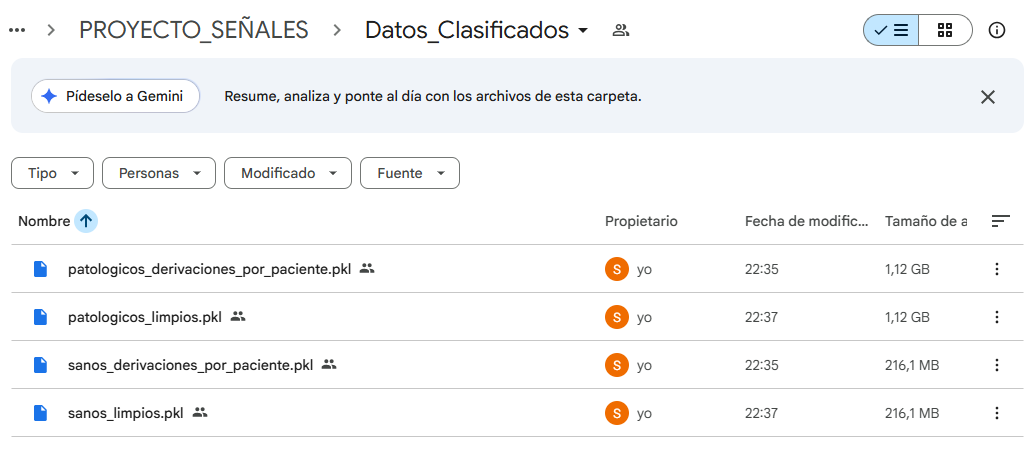

###Ploteamos para ver el efecto del acondicionamiento: ***(Filtro Notch + Pasabanda + Filtfilt)***

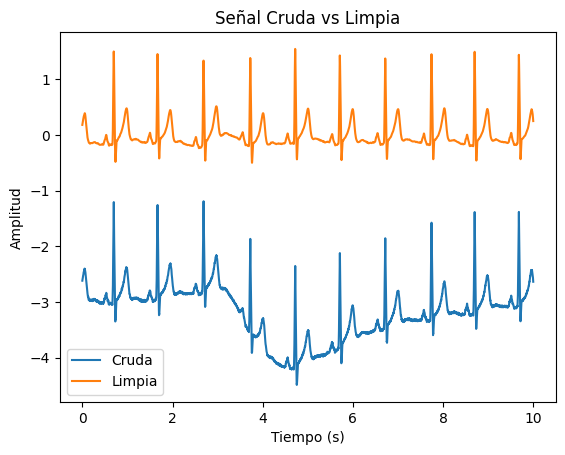

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
#Carga de los datos:
with open(os.path.join(ruta_drive,'sanos_derivaciones_por_paciente.pkl'), 'rb') as f:
    sanos_crudos = pickle.load(f)
with open(os.path.join(ruta_drive, 'sanos_limpios.pkl'), 'rb') as f:
    sanos_limpios = pickle.load(f)
#Extraemos el primero
paciente = list(sanos_crudos.keys())[0]
senal_cruda = sanos_crudos[paciente][0][:, 1]
senal_limpia = sanos_limpios[paciente][0][:, 1]
#Parametros
fs = 1000
N = 10000  #Plotearemos solo los tres primeros segundos (1000 samples x seg)
t = np.arange(N) / fs
#Graficamos
plt.figure()
plt.plot(t,senal_cruda[:N], label='Cruda')
plt.plot(t,senal_limpia[:N], label='Limpia')
plt.title('Señal Cruda vs Limpia')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

###Detección de picos R: ***Usamos neurokit2***

Con nk_ecg_peaks nos vamos a ahorrar la determinación de los picos R, este comando del neurokit es una versión optimizada del algoritmo Pan-Tompkins. No vamos a usar las tres derivaciones, solo la II ya que es la mejor para determinar estos y tiene el pico R más pronunciado

In [ ]:
!pip install neurokit2
import os
import pickle
import numpy as np
import neurokit2 as nk
ruta_drive = '/content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados'
def detectar_picos_r(nombre_archivo_entrada, nombre_archivo_salida):
    ruta_entrada = os.path.join(ruta_drive, nombre_archivo_entrada)
    ruta_salida = os.path.join(ruta_drive, nombre_archivo_salida)
    #Para ver que funciona después lo borro:
    print(f"Abriendo {nombre_archivo_entrada}")
    with open(ruta_entrada, 'rb') as f:
        datos_limpios = pickle.load(f)
    datos_picos = {}
    for paciente, lista_matrices in datos_limpios.items():
        picos_del_paciente = []
        for matriz in lista_matrices:
            #Extraemos solo la derivación 2
            derivacion_ii = matriz[:, 1]
            try:
                #Usamos la función de neurokit para sacar los picos
                _,info_picos = nk.ecg_peaks(derivacion_ii, sampling_rate=1000)
                # Extraemos el arreglo con las posiciones exactas de los picos
                ubicacion_picos = info_picos["ECG_R_Peaks"]
                picos_del_paciente.append(ubicacion_picos)
            except Exception as e:
                # Si algún registro está dañado, lo ignoramos para no tumbar el código
                pass
        # Guardamos la lista de picos bajo el ID del paciente
        if picos_del_paciente:
            datos_picos[paciente] = picos_del_paciente
    with open(ruta_salida, 'wb') as f:
        pickle.dump(datos_picos, f)
    print(f"Picos guardados en: {ruta_salida}\n")
    return datos_picos
# Ejecutamos la detección masiva para sanos y patológicos
sanos_picos = detectar_picos_r('sanos_limpios.pkl', 'sanos_picos.pkl')
patologicos_picos = detectar_picos_r('patologicos_limpios.pkl', 'patologicos_picos.pkl')
print("Listo")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 9.5 MB/s eta 0:00:00
Abriendo sanos_limpios.pkl
Picos guardados en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/sanos_picos.pkl

Abriendo patologicos_limpios.pkl
Picos guardados en: /content/drive/MyDrive/INTRODUCCION_A_SEÑALES/PROYECTO_SEÑALES/Datos_Clasificados/patologicos_picos.pkl

Listo
